In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.5 MB/s eta 0:00:00


Trial 5 Complete [00h 00m 26s]
val_accuracy: 0.9591666460037231

Best val_accuracy So Far: 0.9591666460037231
Total elapsed time: 00h 02m 22s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9544 - loss: 0.2205

Best Test Accuracy: 0.9544000029563904

Best Hyperparameters:
Units: 192
Dropout: 0.0
Learning Rate: 0.01
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step


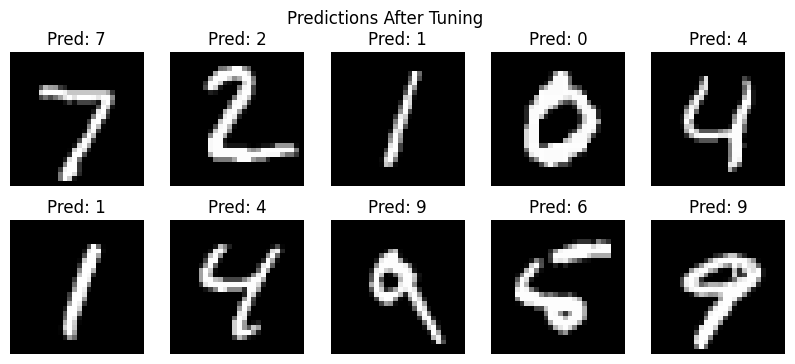

In [ ]:
# ==============================
# 1. Install (run once)
# ==============================
# !pip install keras-tuner

# ==============================
# 2. Import Libraries
# ==============================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 3. Load Dataset
# ==============================
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

# ==============================
# 4. Print Dataset Samples
# ==============================
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle("Sample Dataset")
plt.show()

# ==============================
# 5. Model Building Function
# ==============================
def build_model(hp):
    model = keras.Sequential()

    model.add(layers.Flatten(input_shape=(28,28)))

    # Tune number of neurons
    hp_units = hp.Int('units', min_value=32, max_value=256, step=32)
    model.add(layers.Dense(units=hp_units, activation='relu'))

    # Tune dropout
    hp_dropout = hp.Float('dropout', 0.0, 0.5, step=0.1)
    model.add(layers.Dropout(hp_dropout))

    model.add(layers.Dense(10, activation='softmax'))

    # Tune learning rate
    hp_lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp_lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ==============================
# 6. Random Search Tuner
# ==============================
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='tuner_dir',
    project_name='mnist_tuning'
)

# ==============================
# 7. Search Best Parameters
# ==============================
tuner.search(X_train, y_train, epochs=5, validation_split=0.2)

# ==============================
# 8. Get Best Model
# ==============================
best_model = tuner.get_best_models(num_models=1)[0]

# ==============================
# 9. Evaluate Model
# ==============================
test_loss, test_acc = best_model.evaluate(X_test, y_test)

print("\nBest Test Accuracy:", test_acc)

# ==============================
# 10. Best Hyperparameters
# ==============================
best_hp = tuner.get_best_hyperparameters(1)[0]

print("\nBest Hyperparameters:")
print("Units:", best_hp.get('units'))
print("Dropout:", best_hp.get('dropout'))
print("Learning Rate:", best_hp.get('learning_rate'))

# ==============================
# 11. Predictions
# ==============================
predictions = best_model.predict(X_test[:10])

plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i], cmap='gray')
    pred_label = np.argmax(predictions[i])
    plt.title(f"Pred: {pred_label}")
    plt.axis('off')
plt.suptitle("Predictions After Tuning")
plt.show()